In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Downloaded Dataset Path (in google drive)
DATASET_PATH = "./data"
IMG_CLASSES = ['NORMAL', 'PNEUMONIA']

def load_sample_imgs(path):
    imgs = []
    for cls in IMG_CLASSES:
        dir_path = os.path.join(path, cls)
        img_name = os.listdir(dir_path)[0]
        img = cv2.imread(os.path.join(dir_path, img_name))
        cls_index = IMG_CLASSES.index(cls)
        imgs.append([img, cls_index])

    return imgs

In [6]:
#IMG_SIZE represents height and width of an image
IMG_SIZE = 150

def load_data(path):
    data = []
    for cls in IMG_CLASSES:
        cls_path = os.path.join(path, cls)
        cls_index = IMG_CLASSES.index(cls)
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                data.append([img, cls_index])
    return data

train_data = load_data(os.path.join(DATASET_PATH, 'train'))
valid_data = load_data(os.path.join(DATASET_PATH, 'val'))

# print number of images in each dataset
print(f'There are {len(train_data)} Training Images.')
print(f'There are {len(valid_data)} Validation Images.')

There are 5216 Training Images.
There are 16 Validation Images.


In [7]:
from sklearn.model_selection import train_test_split

all_data = train_data + valid_data

train_data, valid_data = train_test_split(all_data, test_size=0.2, random_state=42)

# print number of images in each dataset
print(f'There are {len(train_data)} Training Images.')
print(f'There are {len(valid_data)} Validation Images.')

There are 4185 Training Images.
There are 1047 Validation Images.


In [8]:
def split_features_labels(data):
    features = np.array([item[0] for item in data]) / 255.0
    labels = np.array([item[1] for item in data])
    return features, labels

x_train, y_train = split_features_labels(train_data)
x_valid, y_valid = split_features_labels(valid_data)

In [9]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [10]:
print(f'Training Labels Tensor Shape: {y_train.shape}')
print(f'Validation Labels Tensor Shape: {y_valid.shape}')

Training Labels Tensor Shape: (4185, 2)
Validation Labels Tensor Shape: (1047, 2)


# Can we collapse RGB data to 1 Monochrome Channel

Text(0.5, 0.98, 'Different Channels of Chest X-Ray Image')

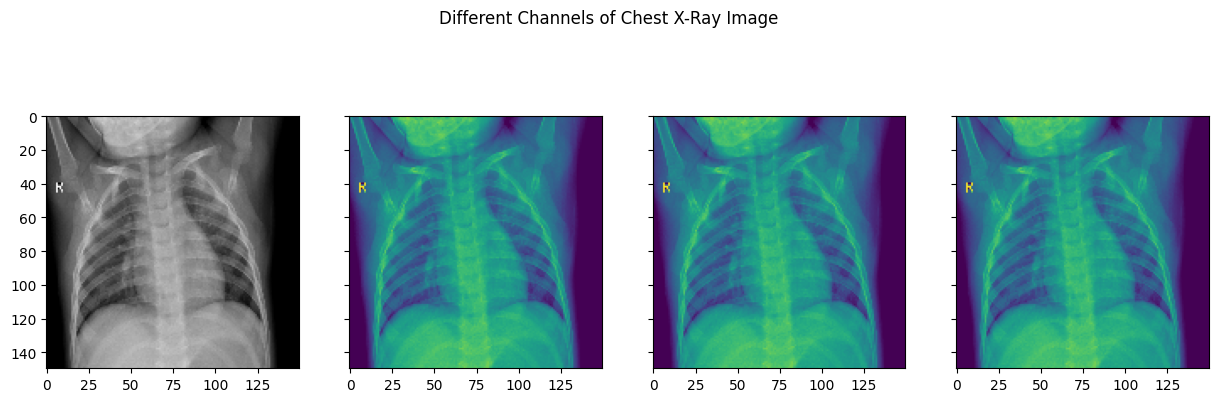

In [11]:
image = x_train[0]

# plotting the original image and the RGB channels
f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, sharey=True)
f.set_figwidth(15)
ax1.imshow(image)

# RGB channels
# CHANNELID : 0 for Red, 1 for Green, 2 for Blue.
ax2.imshow(image[:, : , 0]) #Red
ax3.imshow(image[:, : , 1]) #Green
ax4.imshow(image[:, : , 2]) #Blue
f.suptitle('Different Channels of Chest X-Ray Image')

In [ ]:
# check whether the RGB channels are the same
print((x_train[:, :, :, 0] == x_train[:, :, :, 1]).all())
print((x_train[:, :, :, 0] == x_train[:, :, :, 2]).all())
print((x_train[:, :, :, 1] == x_train[:, :, :, 2]).all())

True
True
True


Collapsing to 1 monochrome channel will not lose any information